# NYC Airbnb Listing Segmentation

**Question:**
Is it possible to identify clear separation between market segments in NYC Airbnb listings? What strategic consequences would each of those segments have for Airbnb? Is there demand distinction between neighbourhoods?

**Approach:** Unsupervised k-means clustering on listing-level behavioural features, followed by interpretation against room type and borough.

**Dataset:** AB_NYC_2019.csv from Kaggle. Place the file in the same folder as this notebook before running.

## 1. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

## 2. Load and inspect

In [14]:
df = pd.read_csv('AB_NYC_2019.csv') # Assuming the file is directly uploaded to the Colab session
print(f'Shape: {df.shape}')
df.head()

Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [17]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## 3. Preprocessing

- Drop listings with price = 0 (data errors).
- Cap extreme price outliers at the 99th percentile to stop them dominating the clustering.
- Fill missing `reviews_per_month` with 0 (genuinely zero reviews, not missing).
- Log-transform price because it is heavily right-skewed.

In [18]:
df = df[df['price'] > 0].copy()
price_cap = df['price'].quantile(0.99)
df['price'] = df['price'].clip(upper=price_cap)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['log_price'] = np.log1p(df['price'])
print(f'After cleaning: {df.shape[0]:,} listings')

After cleaning: 48,884 listings


In [19]:
features = [
    'log_price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'calculated_host_listings_count'
]

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Features used for clustering:')
print(features)

Features used for clustering:
['log_price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count']


## 4. Choose k (elbow + silhouette)

Run k-means for k = 2..8, plot inertia (elbow) and silhouette score. Pick k where the elbow flattens AND silhouette is reasonable.

In [20]:
ks = range(2, 9)
inertias = []
silhouettes = []

sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=min(10000, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, km.predict(X_sample))
    silhouettes.append(sil)
    print(f'k={k}: inertia={km.inertia_:.0f}, silhouette={sil:.3f}')

k=2: inertia=238328, silhouette=0.352
k=3: inertia=196025, silhouette=0.382
k=4: inertia=158385, silhouette=0.364
k=5: inertia=133626, silhouette=0.359
k=6: inertia=115086, silhouette=0.288
k=7: inertia=102119, silhouette=0.298
k=8: inertia=92642, silhouette=0.303


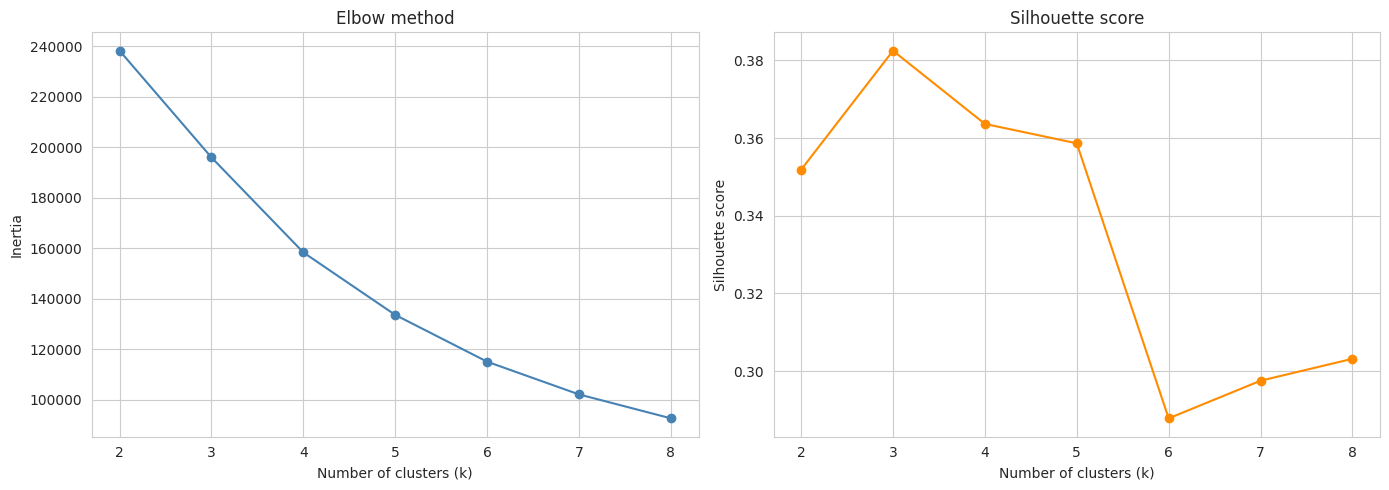

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(ks), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method')

axes[1].plot(list(ks), silhouettes, 'o-', color='darkorange')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score')

plt.tight_layout()
plt.savefig('fig1_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Fit final model

k=4 typically falls out cleanly on this dataset. Adjust `K` below if your elbow/silhouette suggests otherwise.

In [22]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
print(df['cluster'].value_counts().sort_index())

cluster
0     7360
1    12163
2    28802
3      559
Name: count, dtype: int64


## 6. Interpret clusters

Look at the un-scaled mean of each feature per cluster. This tells you the personality of each segment.

In [23]:
summary = df.groupby('cluster').agg(
    listings=('id', 'count'),
    median_price=('price', 'median'),
    mean_min_nights=('minimum_nights', 'mean'),
    mean_reviews=('number_of_reviews', 'mean'),
    mean_reviews_per_month=('reviews_per_month', 'mean'),
    mean_availability=('availability_365', 'mean'),
    mean_host_listings=('calculated_host_listings_count', 'mean')
).round(1)
summary

,listings,median_price,mean_min_nights,mean_reviews,mean_reviews_per_month,mean_availability,mean_host_listings
cluster,,,,,,,
0,7360,99.0,2.5,98.1,3.9,153.7,2.1
1,12163,130.0,14.6,13.9,0.8,290.0,10.2
2,28802,100.0,4.7,8.5,0.5,24.2,1.7
3,559,252.0,21.2,2.3,0.7,281.7,287.6


In [24]:
room_by_cluster = pd.crosstab(df['cluster'], df['room_type'], normalize='index') * 100
room_by_cluster.round(1)

room_type,Entire home/apt,Private room,Shared room
cluster,,,
0,49.5,48.5,2.0
1,54.6,41.9,3.5
2,50.6,47.3,2.0
3,98.6,1.4,0.0


In [25]:
borough_by_cluster = pd.crosstab(df['cluster'], df['neighbourhood_group'], normalize='index') * 100
borough_by_cluster.round(1)

neighbourhood_group,Bronx,Brooklyn,Manhattan,Queens,Staten Island
cluster,,,,,
0,3.2,41.5,37.8,16.3,1.2
1,2.9,35.0,47.5,13.3,1.3
2,1.7,44.4,43.6,9.9,0.4
3,0.0,0.4,99.6,0.0,0.0


## 7. Visualisations for the report

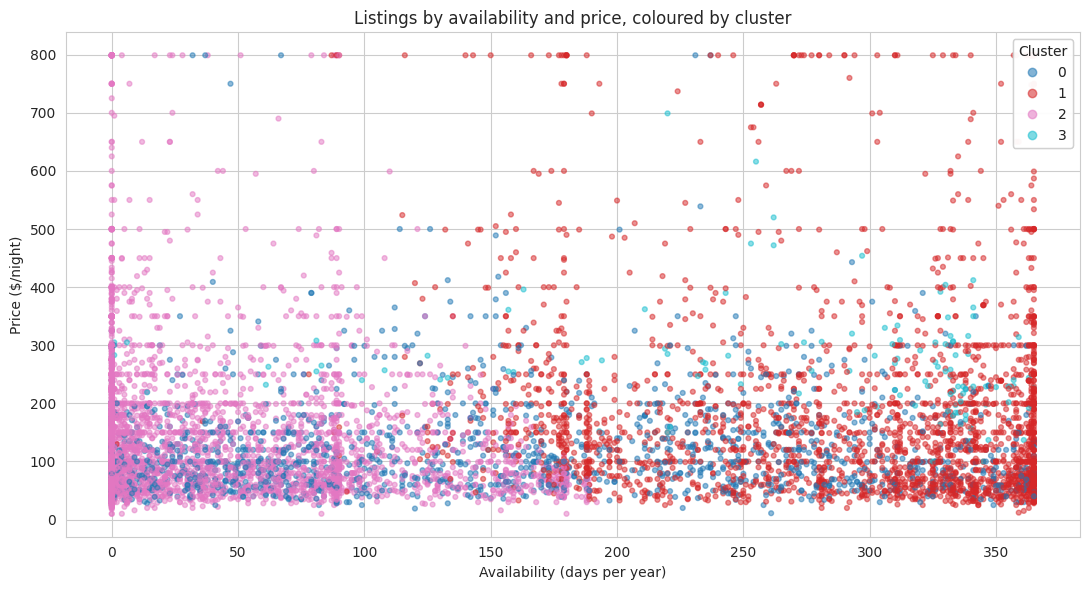

In [26]:
fig, ax = plt.subplots(figsize=(11, 6))
sample = df.sample(n=min(10000, len(df)), random_state=RANDOM_STATE)
scatter = ax.scatter(
    sample['availability_365'],
    sample['price'],
    c=sample['cluster'],
    cmap='tab10',
    alpha=0.5,
    s=12
)
ax.set_xlabel('Availability (days per year)')
ax.set_ylabel('Price ($/night)')
ax.set_title('Listings by availability and price, coloured by cluster')
legend = ax.legend(*scatter.legend_elements(), title='Cluster', loc='upper right')
ax.add_artist(legend)
plt.tight_layout()
plt.savefig('fig2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

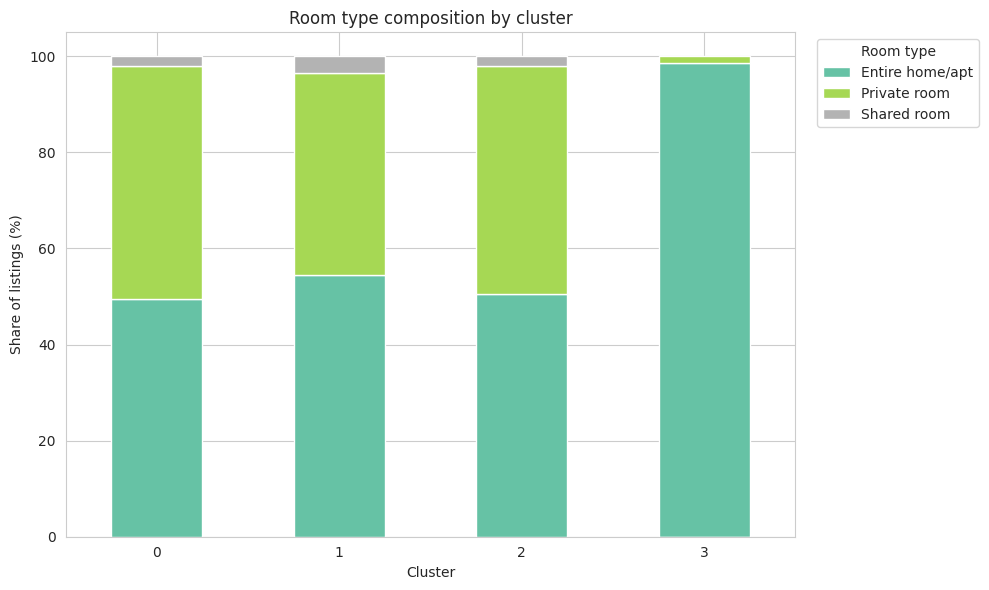

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
room_by_cluster.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_xlabel('Cluster')
ax.set_ylabel('Share of listings (%)')
ax.set_title('Room type composition by cluster')
ax.legend(title='Room type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig3_room_type.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Naming the segments

Look at the summary table above and label each cluster. Typical pattern on this dataset:

- **Commercial operators** — high availability, multi-listing hosts, entire-home dominant, Manhattan-heavy.
- **Occasional hosts** — low availability, private rooms, single-listing hosts, outer boroughs.
- **Popular tourist rentals** — high reviews-per-month, moderate price, healthy availability.
- **Dormant listings** — very low availability, almost no reviews, suggesting near-inactive supply.

Edit the dictionary below to match your actual cluster numbers (run summary first to see which is which).

In [28]:
cluster_names = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3'
}
df['segment'] = df['cluster'].map(cluster_names)
df['segment'].value_counts()

,count
segment,
Cluster 2,28802
Cluster 1,12163
Cluster 0,7360
Cluster 3,559


## 9. Recommendations skeleton

Once segments are named, write one recommendation per segment in the report:

- **Commercial operators** — trust-and-safety review, regulatory exposure (NYC short-term rental laws), professional-host tooling.
- **Occasional hosts** — onboarding support, smart pricing nudges, retention focus.
- **Popular tourist rentals** — promote in search ranking, case-study them for new hosts.
- **Dormant listings** — reactivation campaign or prune from search to protect platform quality.

Three figures (elbow, scatter, room-type) plus one summary table is enough for a 1000-word report.